Get the dataset

In [4]:
from sklearn import datasets as ds 

In [7]:
help(datasets)

Help on package sklearn.datasets in sklearn:

NAME
    sklearn.datasets

DESCRIPTION
    The :mod:`sklearn.datasets` module includes utilities to load datasets,
    including methods to load and fetch popular reference datasets. It also
    features some artificial data generators.

PACKAGE CONTENTS
    _arff_parser
    _base
    _california_housing
    _covtype
    _kddcup99
    _lfw
    _olivetti_faces
    _openml
    _rcv1
    _samples_generator
    _species_distributions
    _svmlight_format_fast
    _svmlight_format_io
    _twenty_newsgroups
    data (package)
    descr (package)
    images (package)
    tests (package)

FUNCTIONS
    __getattr__(name)
    
    clear_data_home(data_home=None)
        Delete all the content of the data home cache.
        
        Parameters
        ----------
        data_home : str, default=None
            The path to scikit-learn data directory. If `None`, the default path
            is `~/sklearn_learn_data`.
    
    dump_svmlight_file(X, y,

In [174]:
ca_houses = ds.fetch_california_housing()
ca_houses

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [176]:
ca_houses.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n    :Number of Instances: 20640\n\n    :Number of Attributes: 8 numeric, predictive attributes and the target\n\n    :Attribute Information:\n        - MedInc        median income in block group\n        - HouseAge      median house age in block group\n        - AveRooms      average number of rooms per household\n        - AveBedrms     average number of bedrooms per household\n        - Population    block group population\n        - AveOccup      average number of household members\n        - Latitude      block group latitude\n        - Longitude     block group longitude\n\n    :Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000

In [178]:
feature_names = ca_houses.feature_names
feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [182]:
Y = ca_houses.target
Y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [184]:
X = ca_houses.data
X ,X.shape

(array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 (20640, 8))

Data Split

In [186]:
from sklearn.model_selection import train_test_split

In [188]:
 X_train, X_test, Y_train, Y_test = train_test_split(X ,Y, test_size = 0.2)

Feature Selection using Lasso Regularization (L1)

In [190]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, Y_train)

Lasso(alpha=0.1)

In [192]:
 X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [194]:
 Y_train.shape, Y_test.shape

((16512,), (4128,))

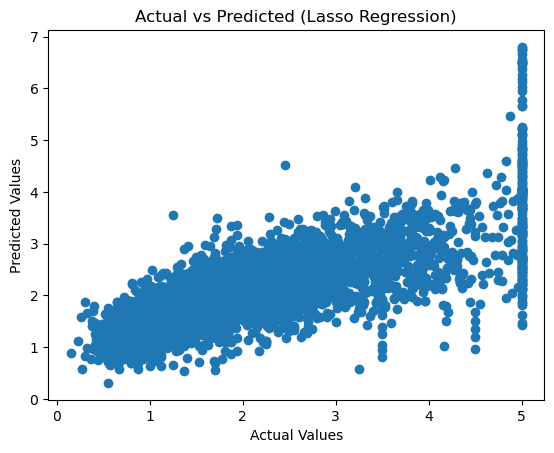

In [198]:
Y_pred = lasso.predict(X_test)

import matplotlib.pyplot as plt 

plt.scatter(Y_test, Y_pred)



plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Lasso Regression)")
plt.show()

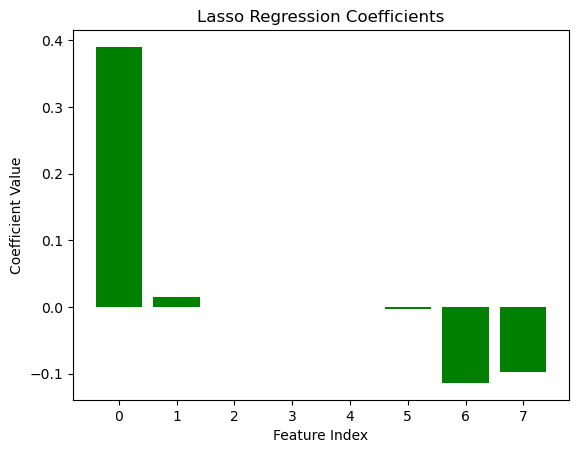

In [200]:

plt.bar(range(len(lasso.coef_)), lasso.coef_, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")
plt.show()

In [212]:
selected_indices = []
selected_features = [(i,feature_names[i],coef) for i, coef in enumerate(lasso.coef_) if abs(coef) >0.01 ]
print("Selected features:")
for index, feature_names[index], coeff in selected_features:
    selected_indices.append(index)
    print(f"Feature {index} ({feature_names[index]}) :{coeff}")
    
print("Selected features indicies:",selected_indices)

Selected features:
Feature 0 (MedInc) :0.38983509785890913
Feature 1 (HouseAge) :0.014761133126983694
Feature 6 (Latitude) :-0.1139074635053293
Feature 7 (Longitude) :-0.09818778972752788
Selected features indicies: [0, 1, 6, 7]


                 Equation -->   y = b+w1*x1+ w1*x1 +...

Linear Regression Model

In [216]:
X_selected = [[row[i] for i in selected_indices]for row in X]
X_selected

[[8.3252, 41.0, 37.88, -122.23],
 [8.3014, 21.0, 37.86, -122.22],
 [7.2574, 52.0, 37.85, -122.24],
 [5.6431, 52.0, 37.85, -122.25],
 [3.8462, 52.0, 37.85, -122.25],
 [4.0368, 52.0, 37.85, -122.25],
 [3.6591, 52.0, 37.84, -122.25],
 [3.12, 52.0, 37.84, -122.25],
 [2.0804, 42.0, 37.84, -122.26],
 [3.6912, 52.0, 37.84, -122.25],
 [3.2031, 52.0, 37.85, -122.26],
 [3.2705, 52.0, 37.85, -122.26],
 [3.075, 52.0, 37.85, -122.26],
 [2.6736, 52.0, 37.84, -122.26],
 [1.9167, 52.0, 37.85, -122.26],
 [2.125, 50.0, 37.85, -122.26],
 [2.775, 52.0, 37.85, -122.27],
 [2.1202, 52.0, 37.85, -122.27],
 [1.9911, 50.0, 37.84, -122.26],
 [2.6033, 52.0, 37.84, -122.27],
 [1.3578, 40.0, 37.85, -122.27],
 [1.7135, 42.0, 37.85, -122.27],
 [1.725, 52.0, 37.84, -122.27],
 [2.1806, 52.0, 37.84, -122.27],
 [2.6, 52.0, 37.84, -122.27],
 [2.4038, 41.0, 37.85, -122.28],
 [2.4597, 49.0, 37.85, -122.28],
 [1.808, 52.0, 37.85, -122.28],
 [1.6424, 50.0, 37.84, -122.28],
 [1.6875, 52.0, 37.84, -122.28],
 [1.9274, 49.0, 37.8

In [218]:
# importing library
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [220]:
# Split again for the linear regression model
X_selected_train, X_selected_test, Y_train, Y_test = train_test_split(X_selected ,Y, test_size = 0.2)

In [222]:

# intiate the the linear model and store it in `model`
model = linear_model.LinearRegression()

In [224]:
# Building the training model
model.fit(X_selected_train,Y_train)

LinearRegression()

In [226]:
# Make predictions on test set
Y_pred = model.predict(X_selected_test)


#Prediction Results (Model performance)

In [229]:
print('coefficients:', model.coef_,
      '\n Intercept:',model.intercept_)

coefficients: [ 0.37714175  0.00961492 -0.45168789 -0.460544  ] 
 Intercept: -38.63093251200133


In [231]:
print('Mean Squared Error (MSE): %.2f' % mean_squared_error(Y_test,Y_pred))

Mean Squared Error (MSE): 0.51


In [233]:
print('Coefficient of determination (R2 Score): %.2f' %r2_score(Y_test,Y_pred))

Coefficient of determination (R2 Score): 0.61


In [235]:
# Visualizing using scatter plot
import seaborn as sns


Text(0, 0.5, 'predicted values')

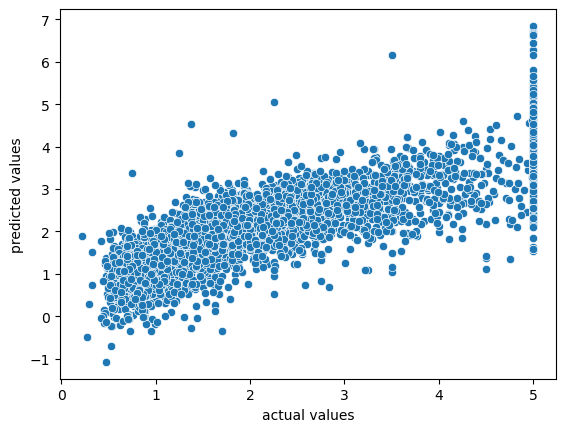

In [237]:
sns.scatterplot(data = cancer_data ,x = Y_test, y = Y_pred)
plt.xlabel("actual values")
plt.ylabel("predicted values")


In conclusion we now have 2 main measures assure that the model is good so far 
   First: high R2-score 
   Second: the diagonal distribution of the point which indicates the error is low 
                   error = |y_test - y_pred|

Gradient Descent

In [248]:
import numpy as np
import matplotlib.pyplot as plt

class GradientDescentLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        
        # Gradient descent
        for i in range(self.iterations):
            # making predictions
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Calculate and store cost (MSE)
            cost = np.mean((y_predicted - y) ** 2)
            self.cost_history.append(cost)
            
            # Print progress every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")
        
        return self
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

Training with Gradient Descent:
Iteration 0: Cost = 5.6515
Iteration 100: Cost = 1.3178
Iteration 200: Cost = 0.7201
Iteration 300: Cost = 0.6304
Iteration 400: Cost = 0.6110
Iteration 500: Cost = 0.6022
Iteration 600: Cost = 0.5956
Iteration 700: Cost = 0.5900
Iteration 800: Cost = 0.5850
Iteration 900: Cost = 0.5807
Gradient Descent Results:
Mean Squared Error: 0.5254
R2 Score: 0.5937
Weights: [ 0.77004887  0.17529918 -0.49862182 -0.45637023]
Bias: 2.0761


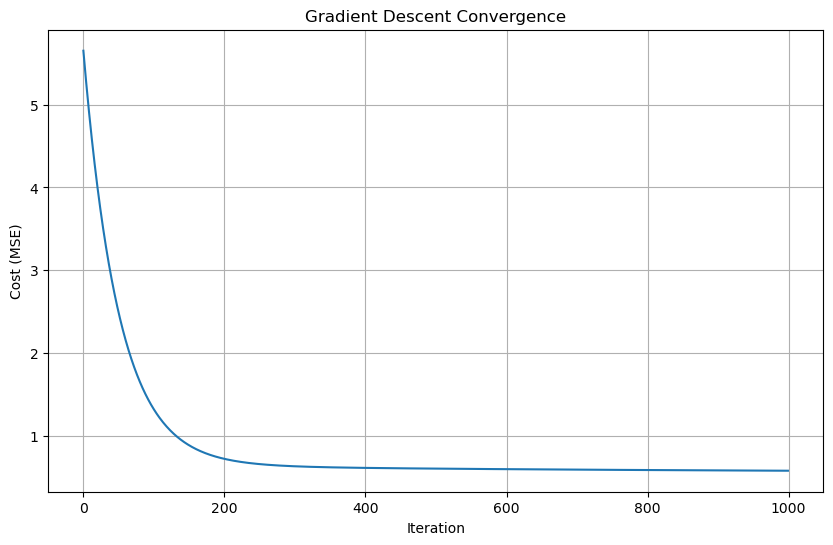

In [250]:
# Scale / Standardize the features to avoid the bias

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_selected_train)
X_test_scaled = scaler.transform(X_selected_test)

print("Training with Gradient Descent:")
gd_model = GradientDescentLinearRegression(learning_rate=0.01, iterations=1000)
gd_model.fit(X_train_scaled, Y_train)

# Make predictions
Y_pred_gd = gd_model.predict(X_test_scaled)

# check the effect of the model
from sklearn.metrics import mean_squared_error, r2_score

print("Gradient Descent Results:")
print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred_gd):.4f}")
print(f"R2 Score: {r2_score(Y_test, Y_pred_gd):.4f}")
print(f"Weights: {gd_model.weights}")
print(f"Bias: {gd_model.bias:.4f}")

# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(gd_model.cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()